# 4. Mô hình mạng nơ-ron MLP (PyTorch)

**Input:** `exps/feature0/`  
**Output:** log thực nghiệm, `exps/feature0/preds/*.npy`, file nộp

BEGIN

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys; sys.path.insert(0, "../../extra")
from config import *
from common import *
from utils import *
display.clear_output()

In [3]:
MEMBER   = "baseline"      # tên/mã thành viên -> file log riêng
NOTEBOOK = "neural network model"
FEATURE_SET = "feature0"
SELECTION   = None
seed_everything()

In [4]:
from models import cv_mlp
x_train, y_train, x_test, test_id = load_feature_set(FEATURE_SET, SELECTION)

[load] feature0: x_train (1460, 289), x_test (1459, 289)


## 4.1. Cấu hình
Baseline: 2 lớp ẩn, **không** dropout, **không** early stopping, 100 epoch.

In [5]:
cfg = dict(hidden=(256, 128), dropout=0.0, lr=1e-3, weight_decay=0.0,
           batch_size=64, epochs=100, patience=None)
RUN_NAME = 'MLP_baseline'

## 4.2. Huấn luyện 5-fold

In [6]:
scores, oof, test_pred, hists = cv_mlp(x_train, y_train, x_test, **cfg)
print('RMSE từng fold:', scores.round(4))
log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, RUN_NAME, scores, cfg, SELECTION)
save_preds(FEATURE_SET, f'{MEMBER}_{RUN_NAME}', oof, test_pred)

RMSE từng fold: [0.1335 0.1392 0.2093 0.1412 0.1175]
[log] MLP_baseline | feature0/all | CV RMSE = 0.14813 ± 0.03169


## 4.3. Learning curve (fold 0)
Train loss giảm mãi trong khi val loss đứng yên → overfit.

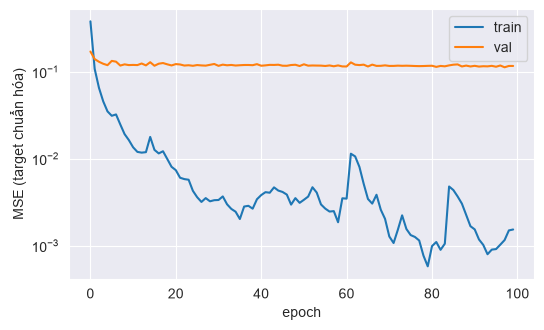

In [7]:
plt.figure(figsize=(6, 3.5))
plt.plot(hists[0]['train'], label='train'); plt.plot(hists[0]['val'], label='val')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE (target chuẩn hóa)'); plt.legend(); plt.show()

In [8]:
save_submission(FEATURE_SET, f'{MEMBER}_{RUN_NAME}', test_id, test_pred)

[submit] d:/HocSau/House_Prices/house_prices_project/exps/feature0\submission_baseline_MLP_baseline.csv


'd:/HocSau/House_Prices/house_prices_project/exps/feature0\\submission_baseline_MLP_baseline.csv'

### Kết luận
- *(ghi nhận xét ở đây)*